# SaaS Customer Churn Prediction Platform
## End-to-End ML Pipeline: Data Engineering → Modelling → Explainability

**Technologies Used in This Project:**

| Layer | Technology | Files |
|---|---|---|
| **Data Storage** | SQL (SQLite/PostgreSQL) | `src/sql/init.sql`, `src/sql/features.sql` |
| **Data Pipeline** | Python (pandas, SQLAlchemy) | `src/data/ingest.py`, `src/data/generate_synthetic.py` |
| **Feature Engineering** | SQL + Python hybrid | `src/sql/features.sql`, `src/data/feature_engineering.py` |
| **ML Training** | scikit-learn, XGBoost | `src/models/train.py` |
| **Experiment Tracking** | MLflow | integrated in training pipeline |
| **Explainability** | SHAP | `src/models/evaluate.py` |
| **Configuration** | Centralised Python config | `src/config.py`, `src/db.py` |
| **Containerisation** | Docker Compose | `docker-compose.yml` |
| **Automation** | Makefile + Bash | `Makefile` |
| **Prediction** | Batch scoring pipeline | `src/models/predict.py` |

This notebook **orchestrates** the modular codebase — all core logic lives in the `src/` modules and `.sql` files, not in this notebook.

---

## 0. Environment Setup (Google Colab)

**Run this cell first** — it mounts Google Drive, navigates to your project folder, and installs dependencies.

⚠️ **Update the `PROJECT_PATH` below** if your project is in a different location on Google Drive.

In [1]:
# ═══════════════════════════════════════════════════════════════
# COLAB SETUP — Run this cell FIRST
# ═══════════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = "/content/drive/MyDrive/Github/Projects/saas-churn-prediction"

import os
os.chdir(PROJECT_PATH)
print(f"Working directory: {os.getcwd()}")

required = ["src/config.py", "src/db.py", "src/data/ingest.py", "src/sql/features.sql", "data/raw/telco_churn_raw.csv"]
missing = [f for f in required if not os.path.exists(f)]
if missing:
    print(f"⚠ Missing files: {missing}")
else:
    print("✓ All project files found")

import sys
sys.path.insert(0, PROJECT_PATH)

!pip install pandas numpy sqlalchemy scikit-learn xgboost shap mlflow matplotlib seaborn joblib -q

print("\n✓ Colab setup complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/Github/Projects/saas-churn-prediction
✓ All project files found

✓ Colab setup complete!


In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

# Create plots directory
PLOTS_DIR = Path("models/plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Libraries imported")
print(f"✓ Plots will be saved to: {PLOTS_DIR}")

✓ Libraries imported
✓ Plots will be saved to: models/plots


---
# Phase 1: Data Pipeline

1. `src/data/ingest.py` — Loads raw CSV, reshapes to SaaS context, writes to SQL database
2. `src/data/generate_synthetic.py` — Creates realistic engagement & support ticket data
3. `src/data/feature_engineering.py` — Runs `src/sql/features.sql` (CTEs, window functions) + Python features

### 1.1 Data Ingestion

In [3]:
from src.data.ingest import run_ingestion

df_ingested = run_ingestion()

SaaS Churn Data Ingestion Pipeline

[1/4] Loading raw data...
  Loaded 7,043 rows, 21 columns from telco_churn_raw.csv

[2/4] Cleaning and reshaping to SaaS context...
  Fixed 11 blank total_revenue values
  Cleaned and reshaped 7,043 rows

[3/4] Connecting to database...

[4/4] Writing tables to database...
  ✓ customers table: 7,043 rows
  ✓ subscriptions table: 7,043 rows
  ✓ product_usage table: 7,043 rows
  Validation — customers: 7,043 rows
  Validation — subscriptions: 7,043 rows
  Validation — product_usage: 7,043 rows

✓ Ingestion complete!


In [4]:
print("\nSample of ingested SaaS data:")
df_ingested[["customer_id", "service_tier", "contract_type", "monthly_revenue", "churn"]].head(10)


Sample of ingested SaaS data:


,customer_id,service_tier,contract_type,monthly_revenue,churn
0,7590-VHVEG,basic,monthly,29.85,0
1,5575-GNVDE,basic,annual,56.95,0
2,3668-QPYBK,basic,monthly,53.85,1
3,7795-CFOCW,basic,annual,42.30,0
4,9237-HQITU,premium,monthly,70.70,1
5,9305-CDSKC,premium,monthly,99.65,1
6,1452-KIOVK,premium,monthly,89.10,0
7,6713-OKOMC,basic,monthly,29.75,0
8,7892-POOKP,premium,monthly,104.80,1
9,6388-TABGU,basic,annual,56.15,0


### 1.2 Synthetic Data Generation

In [5]:
from src.data.generate_synthetic import run_synthetic_generation

run_synthetic_generation()

Synthetic Engagement Data Generation

[1/4] Connecting to database and loading base data...
  Loaded 7,043 customers

[2/4] Generating usage events...
  Generated 28,172 usage event rows (7,043 customers × 4 weeks)

[3/4] Generating support tickets...
  Generated 13,895 support tickets for 5,612 customers

[4/4] Writing to database...
  ✓ usage_events table: 28,172 rows
  ✓ support_tickets table: 13,895 rows

─── Engagement Summary ───
  Avg weekly logins — churners: 4.3, active: 11.8
  Avg tickets — churners: 3.0, active: 2.3

✓ Synthetic data generation complete!


### 1.3 SQL Feature Engineering

Let's look at the actual SQL being executed:

In [6]:
with open("src/sql/features.sql") as f:
    sql_content = f.read()

lines = sql_content.strip().split("\n")
for line in lines[:50]:
    print(line)
print(f"\n... ({len(lines)} total lines of SQL)")

-- =============================================================
-- SaaS Churn Prediction — SQL Feature Engineering
-- =============================================================
-- This file contains the feature engineering logic written in SQL.
-- Demonstrates: CTEs, window functions, aggregations, CASE
-- expressions, and multi-table joins.
--
-- These queries are executed by feature_engineering.py and the
-- results are stored in the 'feature_store' table.
-- =============================================================


-- ─── Feature Set 1: Customer Demographics & Account ──────────
-- Basic customer-level attributes

-- (handled inline in the main query below)


-- ─── Feature Set 2: Subscription & Revenue Features ─────────
-- Revenue patterns, contract risk signals

-- (handled inline in the main query below)


-- ─── Feature Set 3: Product Adoption Features ───────────────
-- Module usage patterns and adoption depth

-- (handled inline in the main query below)


-- ─── Fea

In [7]:
from src.data.feature_engineering import run_feature_engineering

features_df = run_feature_engineering()

Feature Engineering Pipeline

[1/5] Connecting to database...

[2/5] Executing SQL feature queries...
  SQL features generated: 7,043 rows × 40 columns

[3/5] Adding Python-computed features...
  Python features added: now 47 total columns

[4/5] Validating features...

─── Feature Validation ───
  ✓ No null values
  ✓ Churn rate: 26.5% (1,869 / 7,043)
  ✓ Monthly revenue range: £18.25 – £118.75
  ✓ Account age range: 0 – 72 months
  ✓ Avg weekly logins: 9.8 (mean)
  ✓ Total features (excl. customer_id, churn): 45

[5/5] Saving outputs...
  ✓ feature_store table written (7,043 rows)
  ✓ CSV saved to /content/drive/MyDrive/Github/Projects/saas-churn-prediction/data/processed/features.csv

✓ Feature engineering complete! 47 features for 7,043 customers


In [8]:
print(f"\nFeature set: {features_df.shape[0]:,} rows × {features_df.shape[1]} columns")
print(f"\nAll columns:")
for i, col in enumerate(features_df.columns, 1):
    print(f"  {i:2d}. {col}")


Feature set: 7,043 rows × 47 columns

All columns:
   1. customer_id
   2. is_male
   3. is_senior
   4. has_partner
   5. has_dependents
   6. account_age_months
   7. service_tier_encoded
   8. contract_type_encoded
   9. paperless_billing
  10. monthly_revenue
  11. total_revenue
  12. avg_monthly_spend
  13. modules_enabled
  14. has_security_module
  15. has_backup_module
  16. has_protection_module
  17. has_support_addon
  18. has_analytics_module
  19. has_reporting_module
  20. module_adoption_rate
  21. avg_weekly_logins
  22. max_weekly_logins
  23. min_weekly_logins
  24. avg_session_minutes
  25. avg_feature_adoption
  26. total_api_calls
  27. total_pages_viewed
  28. login_trend
  29. session_trend
  30. engagement_risk_flag
  31. total_tickets
  32. critical_tickets
  33. high_severity_tickets
  34. unresolved_tickets
  35. avg_resolution_hours
  36. resolution_rate
  37. support_risk_flag
  38. rule_based_risk_score
  39. churn
  40. revenue_per_module
  41. lifetime_

---
# Phase 2: Exploratory Data Analysis & Modelling

## 2.1 EDA — Understanding Churn Patterns

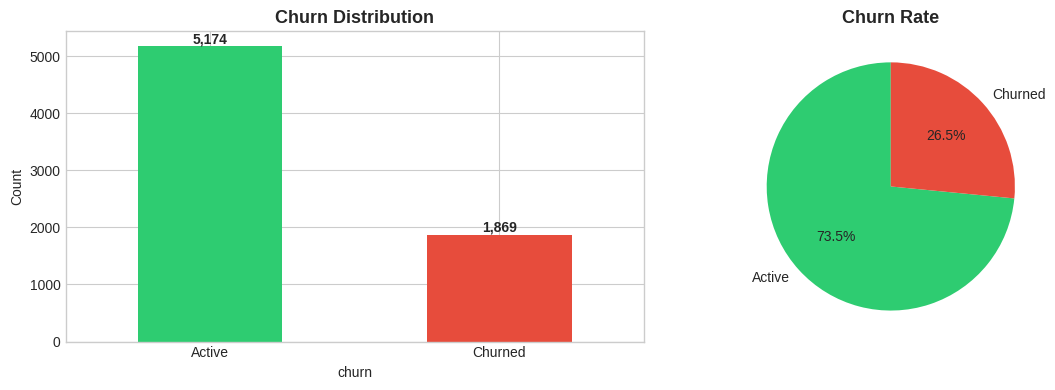

✓ Saved: eda_churn_distribution.png
Class imbalance ratio: 2.8:1


In [9]:
features_df = pd.read_csv("data/processed/features.csv")

# ── Plot 1: Churn Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

features_df["churn"].value_counts().plot(kind="bar", ax=axes[0], color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Churn Distribution", fontsize=13, fontweight="bold")
axes[0].set_xticklabels(["Active", "Churned"], rotation=0)
axes[0].set_ylabel("Count")
for i, v in enumerate(features_df["churn"].value_counts().values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontweight="bold")

features_df["churn"].value_counts().plot(kind="pie", ax=axes[1], labels=["Active", "Churned"],
    autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"], startangle=90)
axes[1].set_title("Churn Rate", fontsize=13, fontweight="bold")
axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "eda_churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"✓ Saved: eda_churn_distribution.png")
print(f"Class imbalance ratio: {features_df['churn'].value_counts()[0] / features_df['churn'].value_counts()[1]:.1f}:1")

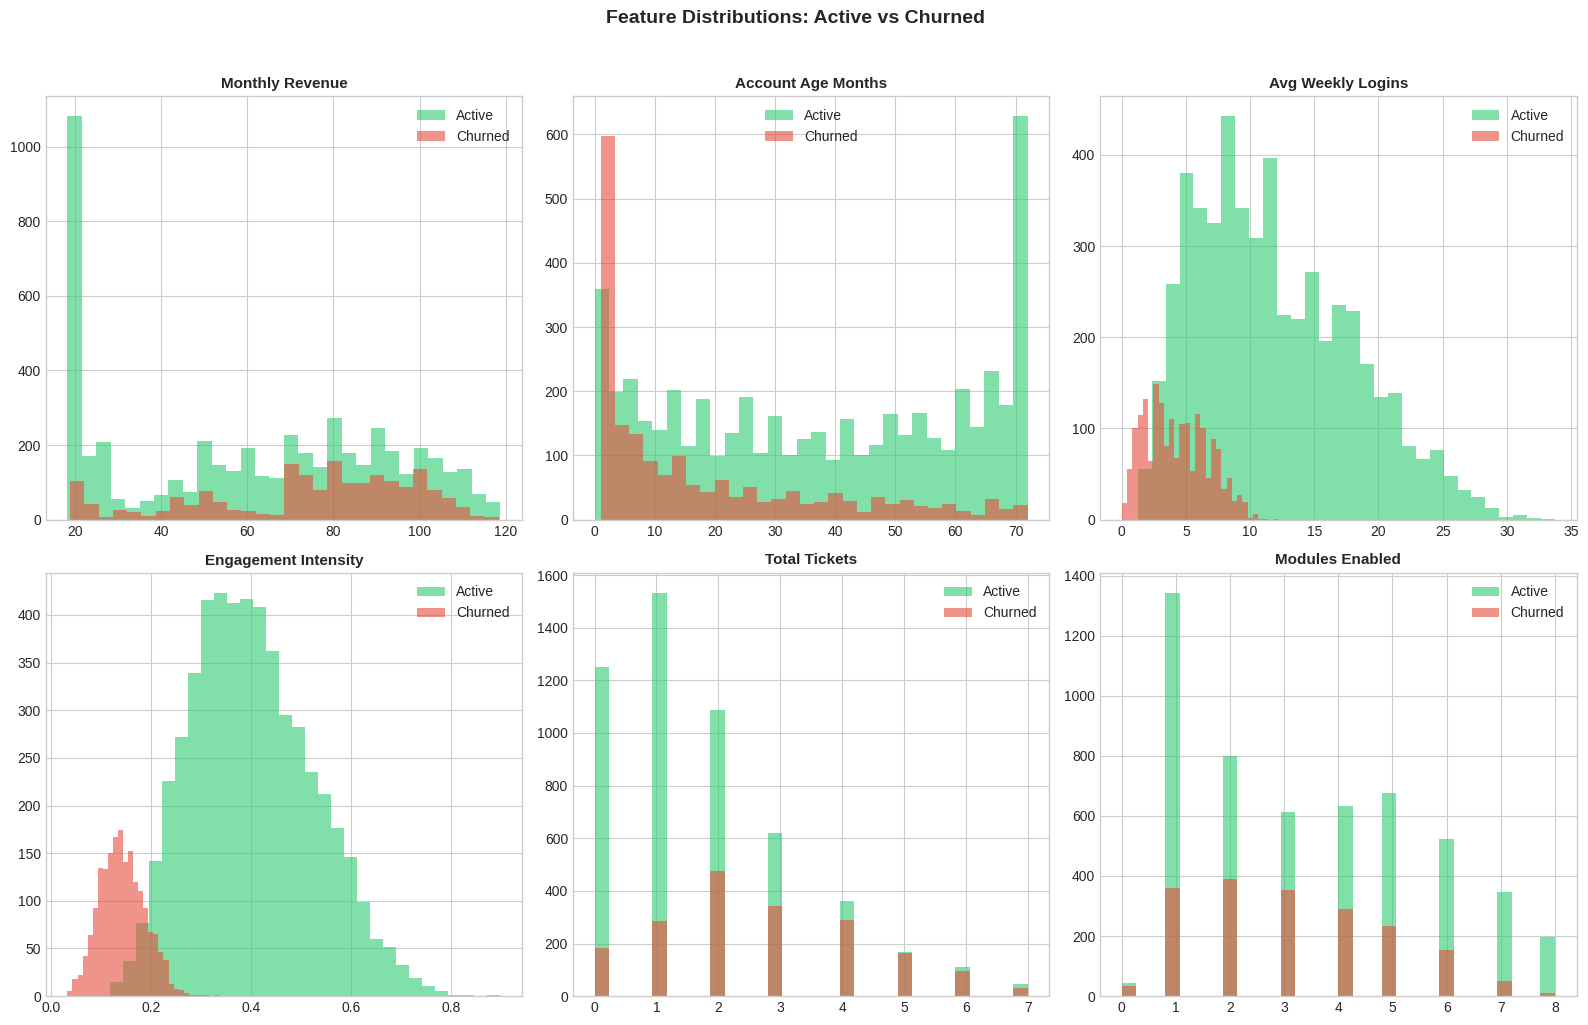

✓ Saved: eda_feature_distributions.png


In [10]:
# ── Plot 2: Feature Distributions by Churn ──
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
plot_features = ["monthly_revenue", "account_age_months", "avg_weekly_logins",
                 "engagement_intensity", "total_tickets", "modules_enabled"]

for ax, feat in zip(axes.flatten(), plot_features):
    for label, color in [(0, "#2ecc71"), (1, "#e74c3c")]:
        subset = features_df[features_df["churn"] == label][feat]
        ax.hist(subset, bins=30, alpha=0.6, color=color, label="Active" if label == 0 else "Churned")
    ax.set_title(feat.replace("_", " ").title(), fontsize=11, fontweight="bold")
    ax.legend()

plt.suptitle("Feature Distributions: Active vs Churned", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "eda_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Saved: eda_feature_distributions.png")

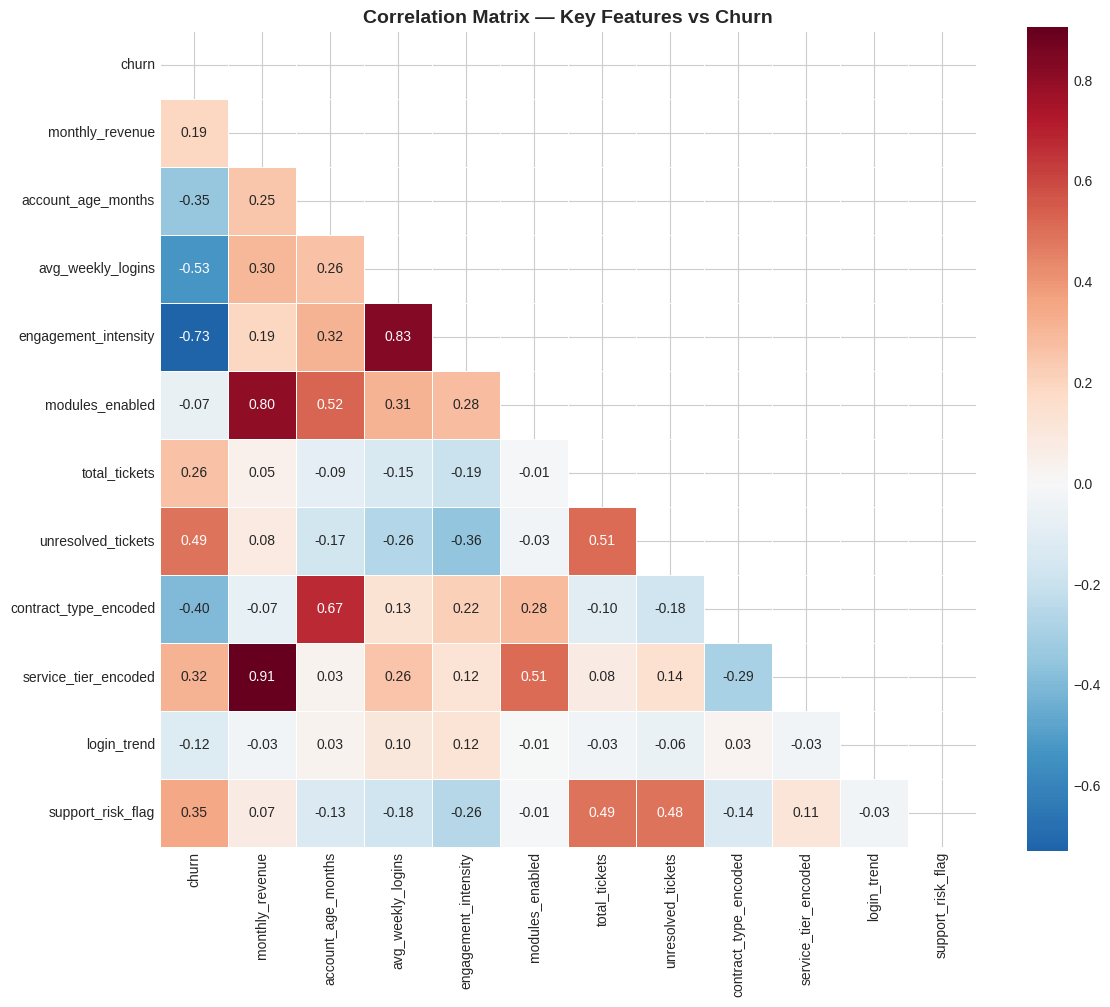

✓ Saved: eda_correlation_heatmap.png


In [11]:
# ── Plot 3: Correlation Heatmap ──
key_features = ["churn", "monthly_revenue", "account_age_months", "avg_weekly_logins",
                "engagement_intensity", "modules_enabled", "total_tickets", "unresolved_tickets",
                "contract_type_encoded", "service_tier_encoded", "login_trend", "support_risk_flag"]

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(features_df[key_features].corr(), dtype=bool))
sns.heatmap(features_df[key_features].corr(), mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix — Key Features vs Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "eda_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Saved: eda_correlation_heatmap.png")

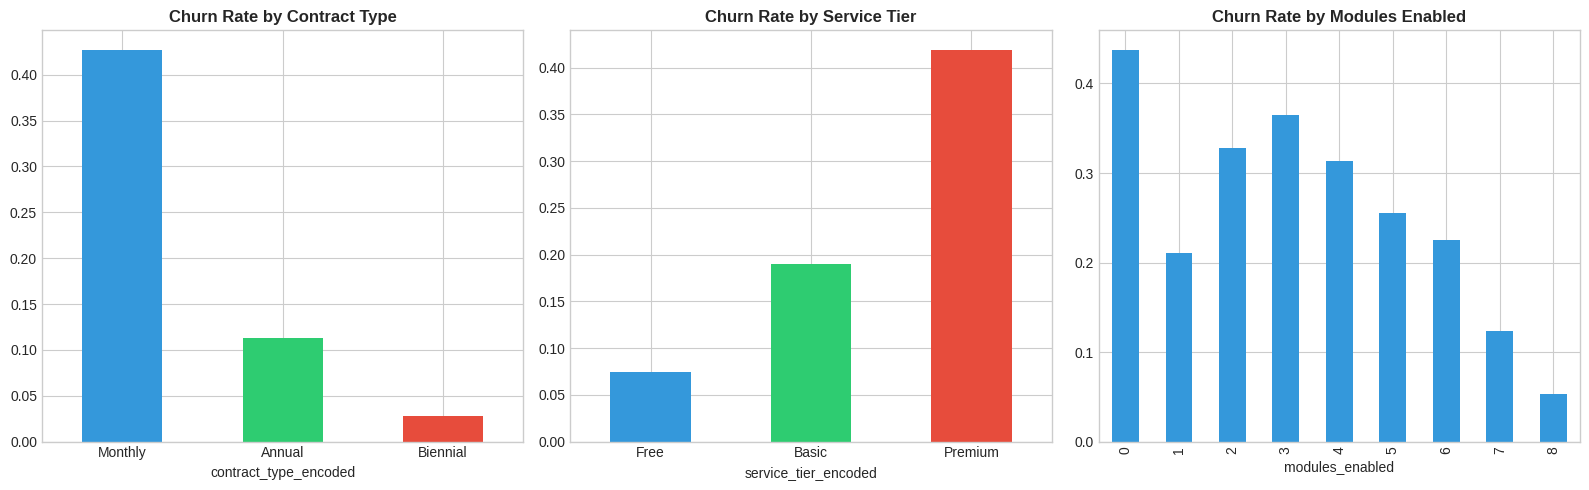

✓ Saved: eda_churn_by_segments.png


In [12]:
# ── Plot 4: Churn Rate by Segments ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

features_df.groupby("contract_type_encoded")["churn"].mean().plot(kind="bar", ax=axes[0], color=["#3498db", "#2ecc71", "#e74c3c"])
axes[0].set_title("Churn Rate by Contract Type", fontweight="bold")
axes[0].set_xticklabels(["Monthly", "Annual", "Biennial"], rotation=0)

features_df.groupby("service_tier_encoded")["churn"].mean().plot(kind="bar", ax=axes[1], color=["#3498db", "#2ecc71", "#e74c3c"])
axes[1].set_title("Churn Rate by Service Tier", fontweight="bold")
axes[1].set_xticklabels(["Free", "Basic", "Premium"], rotation=0)

features_df.groupby("modules_enabled")["churn"].mean().plot(kind="bar", ax=axes[2], color="#3498db")
axes[2].set_title("Churn Rate by Modules Enabled", fontweight="bold")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "eda_churn_by_segments.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Saved: eda_churn_by_segments.png")

## 2.2 Model Training

Calls `src/models/train.py` — trains 3 models with **MLflow** tracking, optimizes threshold, estimates revenue impact.

In [13]:
from src.models.train import run_training

best_model_tuple, results, metadata = run_training()

print(f"\n✓ Best model: {metadata['best_model']}")
print(f"✓ Optimal threshold: {metadata['optimal_threshold']:.4f}")
print(f"✓ Estimated annual savings: £{metadata['revenue_impact']['estimated_annual_savings']:,.2f}")

Model Training Pipeline

[1/6] Loading features...
  Features: 45, Samples: 7043
  Churn rate: 26.5% (1,869 / 7,043)

[2/6] Splitting data...
  Train: 5,634 | Test: 1,409

[3/6] Preprocessing...

[4/6] Training models...

────────────────────────────────────────
  Training: logistic_regression
────────────────────────────────────────

  ─── logistic_regression Results ───
        accuracy: 0.9886
       precision: 0.9613
          recall: 0.9973
              f1: 0.979
         roc_auc: 0.9997

              precision    recall  f1-score   support

      Active       1.00      0.99      0.99      1035
     Churned       0.96      1.00      0.98       374

    accuracy                           0.99      1409
   macro avg       0.98      0.99      0.99      1409
weighted avg       0.99      0.99      0.99      1409

  logistic_regression CV ROC-AUC: 0.9994 ± 0.0001


2026/05/08 21:40:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 21:40:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



────────────────────────────────────────
  Training: random_forest
────────────────────────────────────────

  ─── random_forest Results ───
        accuracy: 0.9894
       precision: 0.9662
          recall: 0.9947
              f1: 0.9802
         roc_auc: 0.9993

              precision    recall  f1-score   support

      Active       1.00      0.99      0.99      1035
     Churned       0.97      0.99      0.98       374

    accuracy                           0.99      1409
   macro avg       0.98      0.99      0.99      1409
weighted avg       0.99      0.99      0.99      1409

  random_forest CV ROC-AUC: 0.9988 ± 0.0004


2026/05/08 21:40:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 21:40:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



────────────────────────────────────────
  Training: xgboost
────────────────────────────────────────

  ─── xgboost Results ───
        accuracy: 0.9929
       precision: 0.974
          recall: 1.0
              f1: 0.9868
         roc_auc: 0.9997

              precision    recall  f1-score   support

      Active       1.00      0.99      1.00      1035
     Churned       0.97      1.00      0.99       374

    accuracy                           0.99      1409
   macro avg       0.99      1.00      0.99      1409
weighted avg       0.99      0.99      0.99      1409

  xgboost CV ROC-AUC: 0.9993 ± 0.0002


2026/05/08 21:40:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



[5/6] Optimizing threshold for best model: logistic_regression

  ─── Optimal Threshold Analysis ───
    Default threshold (0.5) F1: 0.9790
    Optimal threshold: 0.7602
    F1 at optimal: 0.9867
    Precision at optimal: 0.984
    Recall at optimal: 0.9893

  ─── Revenue Impact Estimation ───
    Total MRR at risk (all churners): £27,214.90
    MRR at risk identified by model: £26,945.35
    MRR at risk missed: £269.55
    Estimated monthly savings (20% retention): £5,389.07
    Estimated annual savings: £64,668.84

[6/6] Saving artifacts...
  ✓ Best model saved: /content/drive/MyDrive/Github/Projects/saas-churn-prediction/models/best_model.joblib
  ✓ Scaler saved: /content/drive/MyDrive/Github/Projects/saas-churn-prediction/models/scaler.joblib
  ✓ Metadata saved: /content/drive/MyDrive/Github/Projects/saas-churn-prediction/models/model_metadata.joblib

TRAINING SUMMARY

  Model Comparison:
                     accuracy  precision  recall      f1  roc_auc  cv_roc_auc
logistic_regres

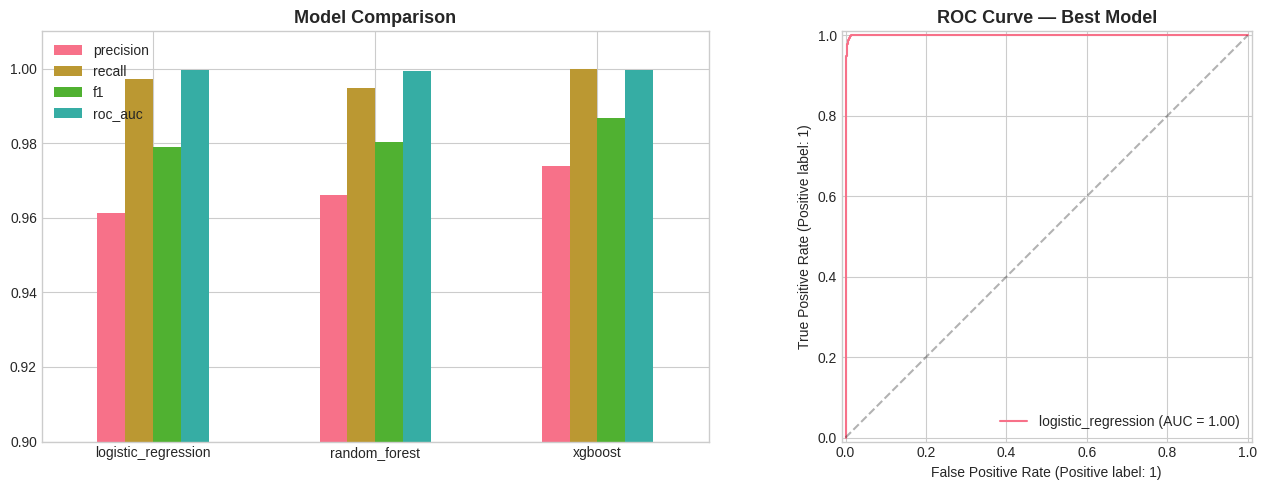

✓ Saved: model_comparison.png


In [14]:
# ── Plot 5: Model Comparison ──
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

RANDOM_STATE = 42

df = pd.read_csv("data/processed/features.csv")
X = df.drop(columns=["customer_id", "churn"])
y = df["churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
scaler.fit(X_train)
X_test_scaled = scaler.transform(X_test)

model = joblib.load("models/best_model.joblib")
meta = joblib.load("models/model_metadata.joblib")

results_df = pd.DataFrame(results).T
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df[["precision", "recall", "f1", "roc_auc"]].plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_title("Model Comparison", fontsize=13, fontweight="bold")
axes[0].set_ylim(0.9, 1.01)

if meta["best_model"] == "logistic_regression":
    RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=axes[1], name=meta["best_model"])
else:
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[1], name=meta["best_model"])
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[1].set_title("ROC Curve — Best Model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Saved: model_comparison.png")

## 2.3 Model Evaluation & SHAP Explainability

Calls `src/models/evaluate.py` — generates ROC curves, confusion matrices, and **SHAP** explanations.
All plots saved automatically to `models/plots/`.

In [15]:
from src.models.evaluate import run_evaluation

run_evaluation()

Model Evaluation & Explainability

[1/4] Loading model and test data...
  Model: logistic_regression
  Threshold: 0.7602

[2/4] Generating evaluation plots...
  ✓ ROC curve saved
  ✓ Precision-Recall curve saved
  ✓ Confusion matrix saved
  ✓ Feature importance plot saved

[3/4] Generating SHAP explanations...
  Computing SHAP values (this may take a minute)...
  ✓ SHAP summary plot saved
  ✓ SHAP bar plot saved
  ✓ SHAP waterfall plot saved

[4/4] Summary...
  All plots saved to: /content/drive/MyDrive/Github/Projects/saas-churn-prediction/models/plots
  Files generated:
    - confusion_matrix.png
    - eda_churn_by_segments.png
    - eda_churn_distribution.png
    - eda_correlation_heatmap.png
    - eda_feature_distributions.png
    - feature_importance.png
    - model_comparison.png
    - precision_recall_curve.png
    - roc_curve.png
    - shap_bar.png
    - shap_summary.png
    - shap_waterfall.png

✓ Evaluation complete!



══════════════════════════════════════════════════
  All plots in models/plots/:
══════════════════════════════════════════════════

── confusion_matrix.png ──


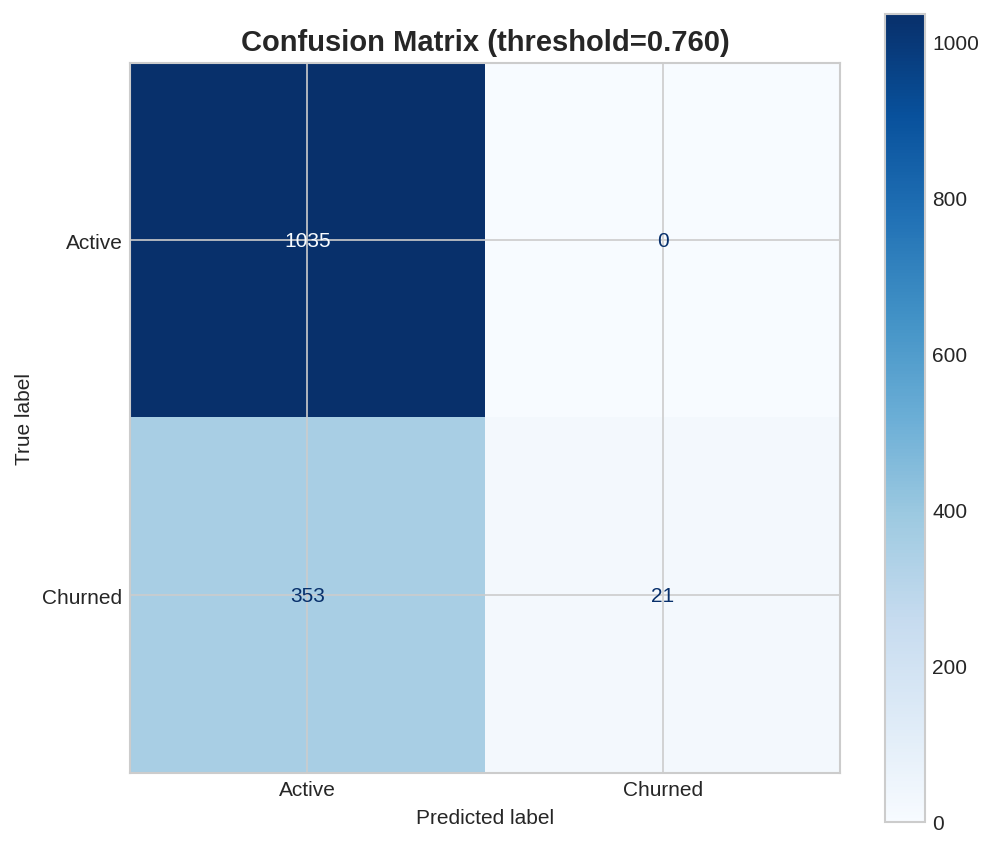


── eda_churn_by_segments.png ──


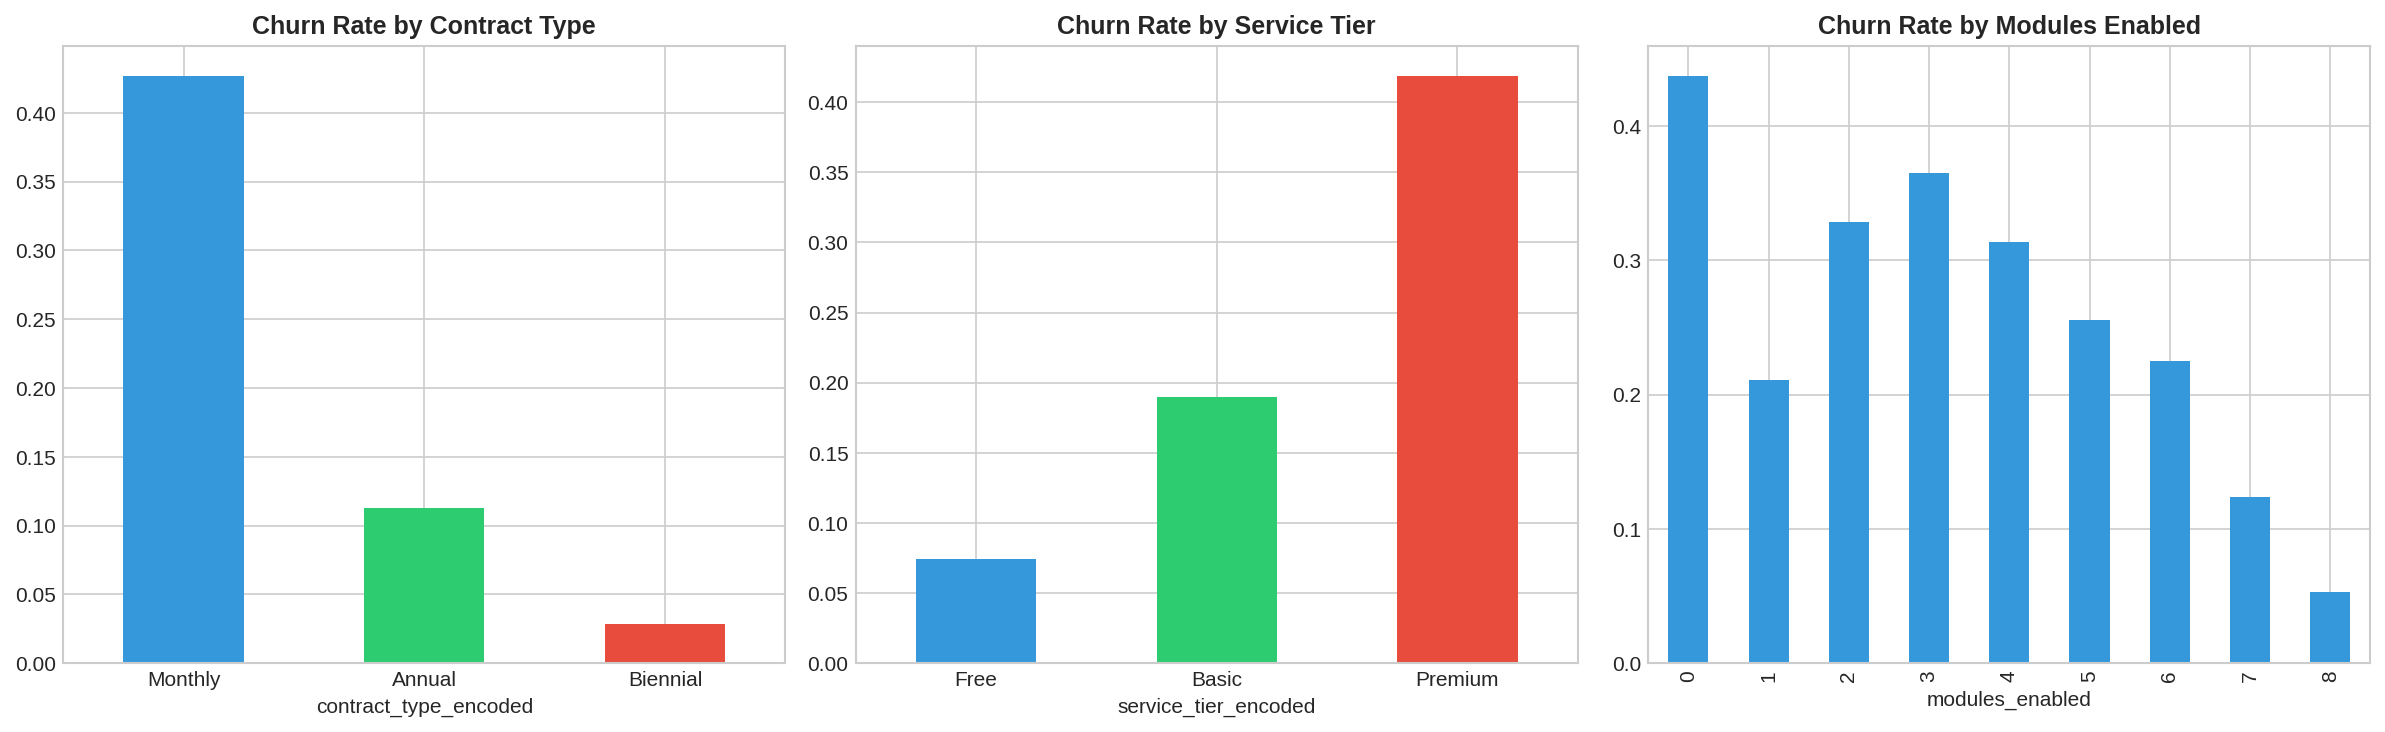


── eda_churn_distribution.png ──


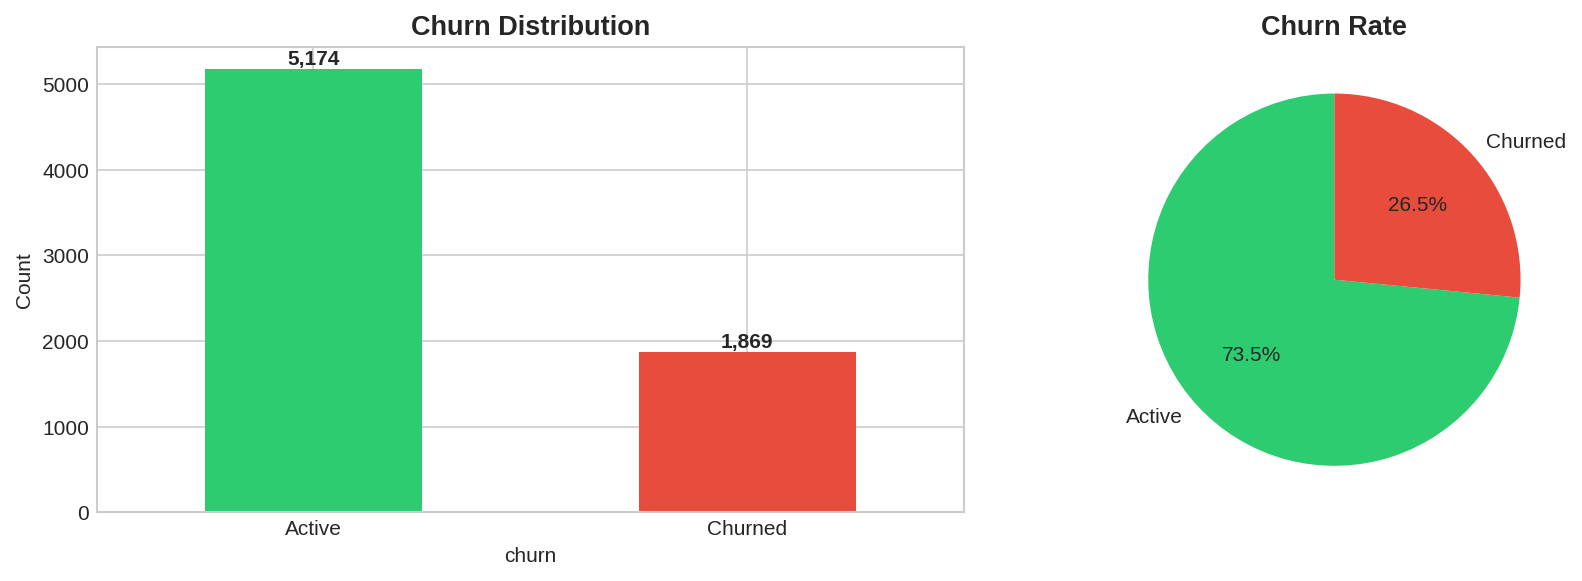


── eda_correlation_heatmap.png ──


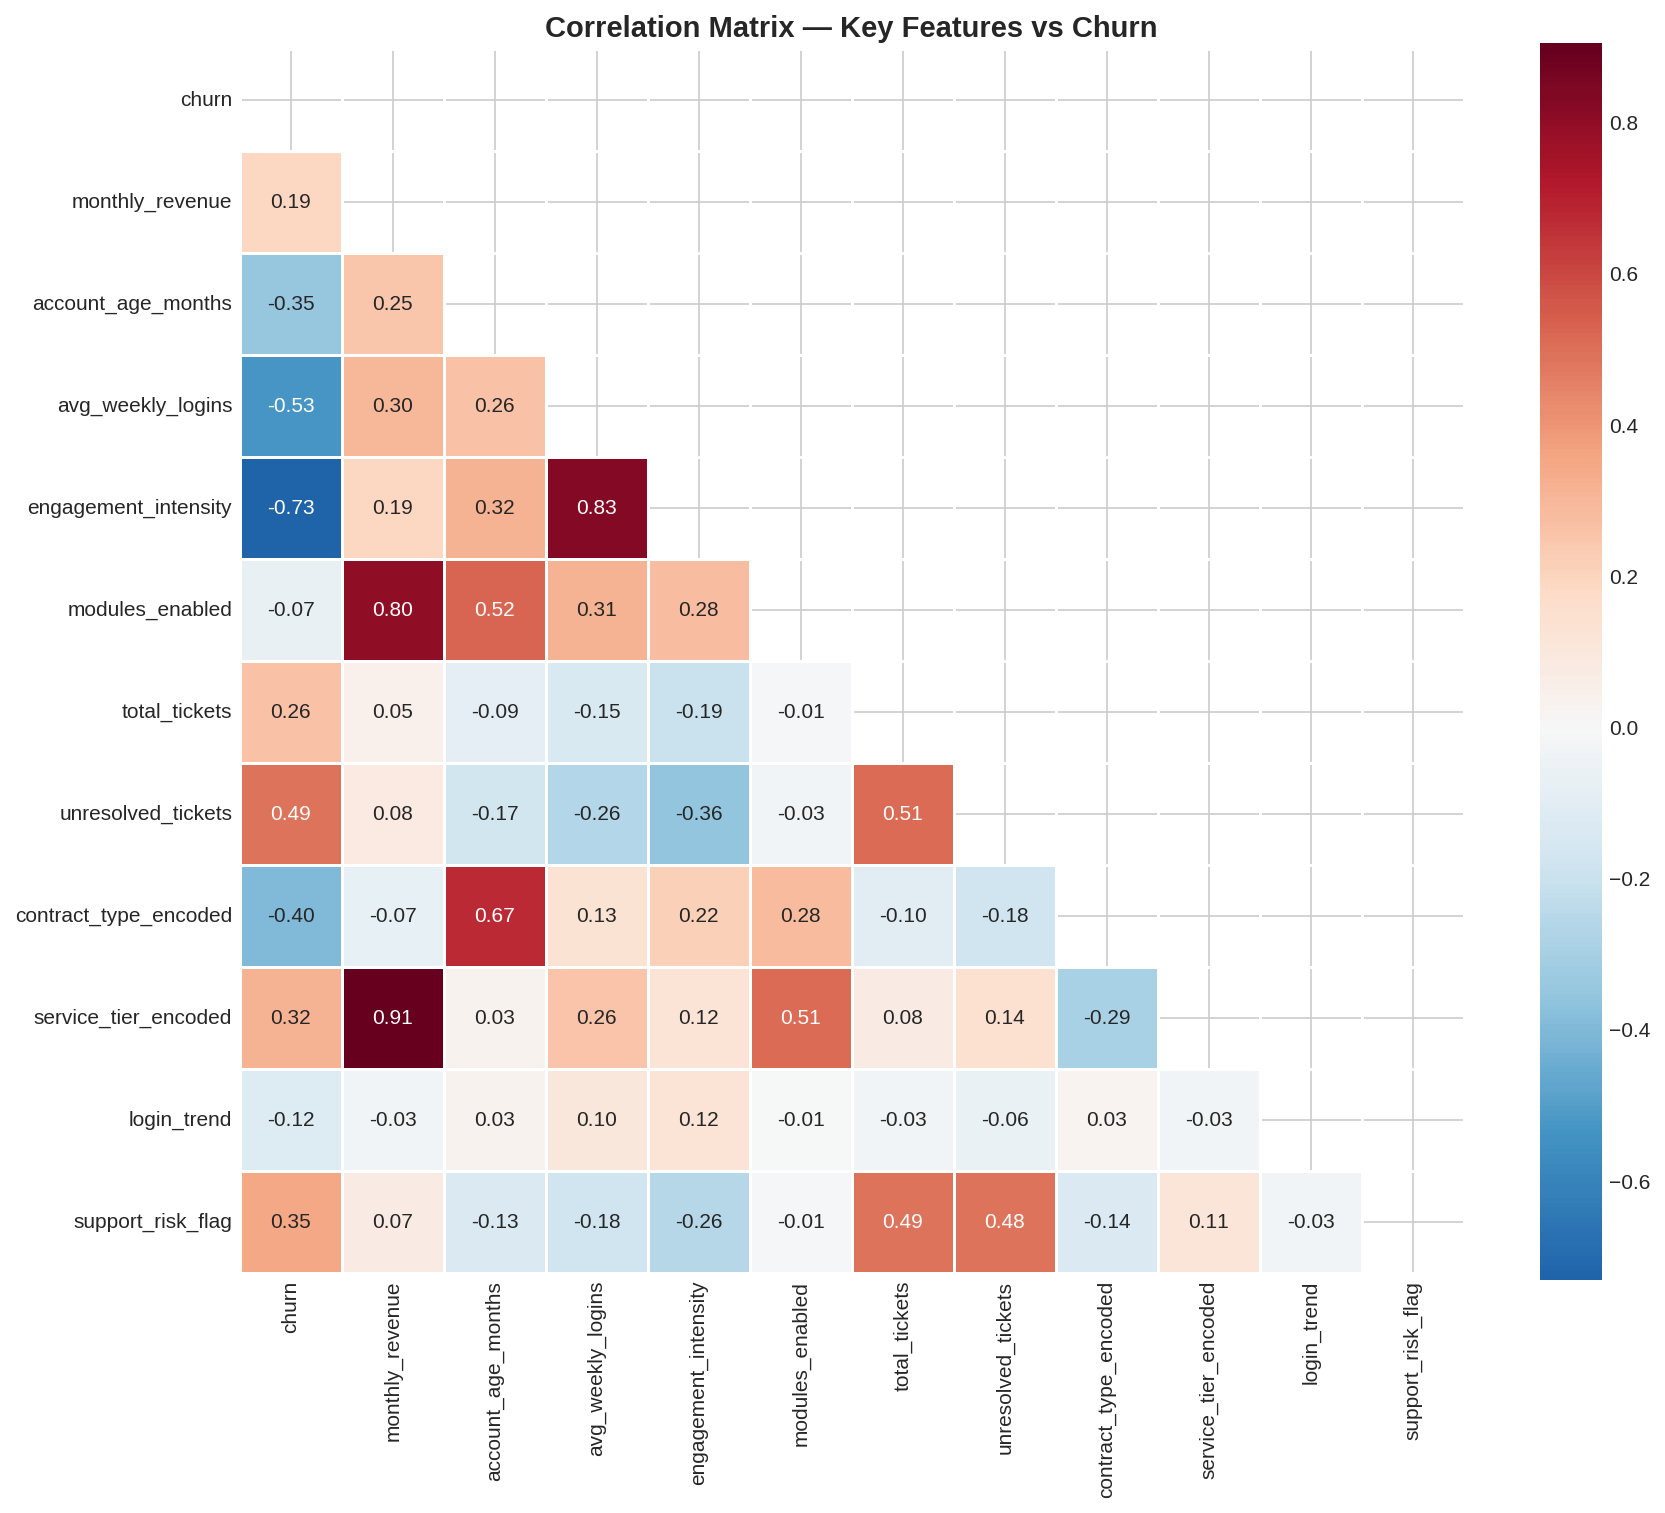


── eda_feature_distributions.png ──


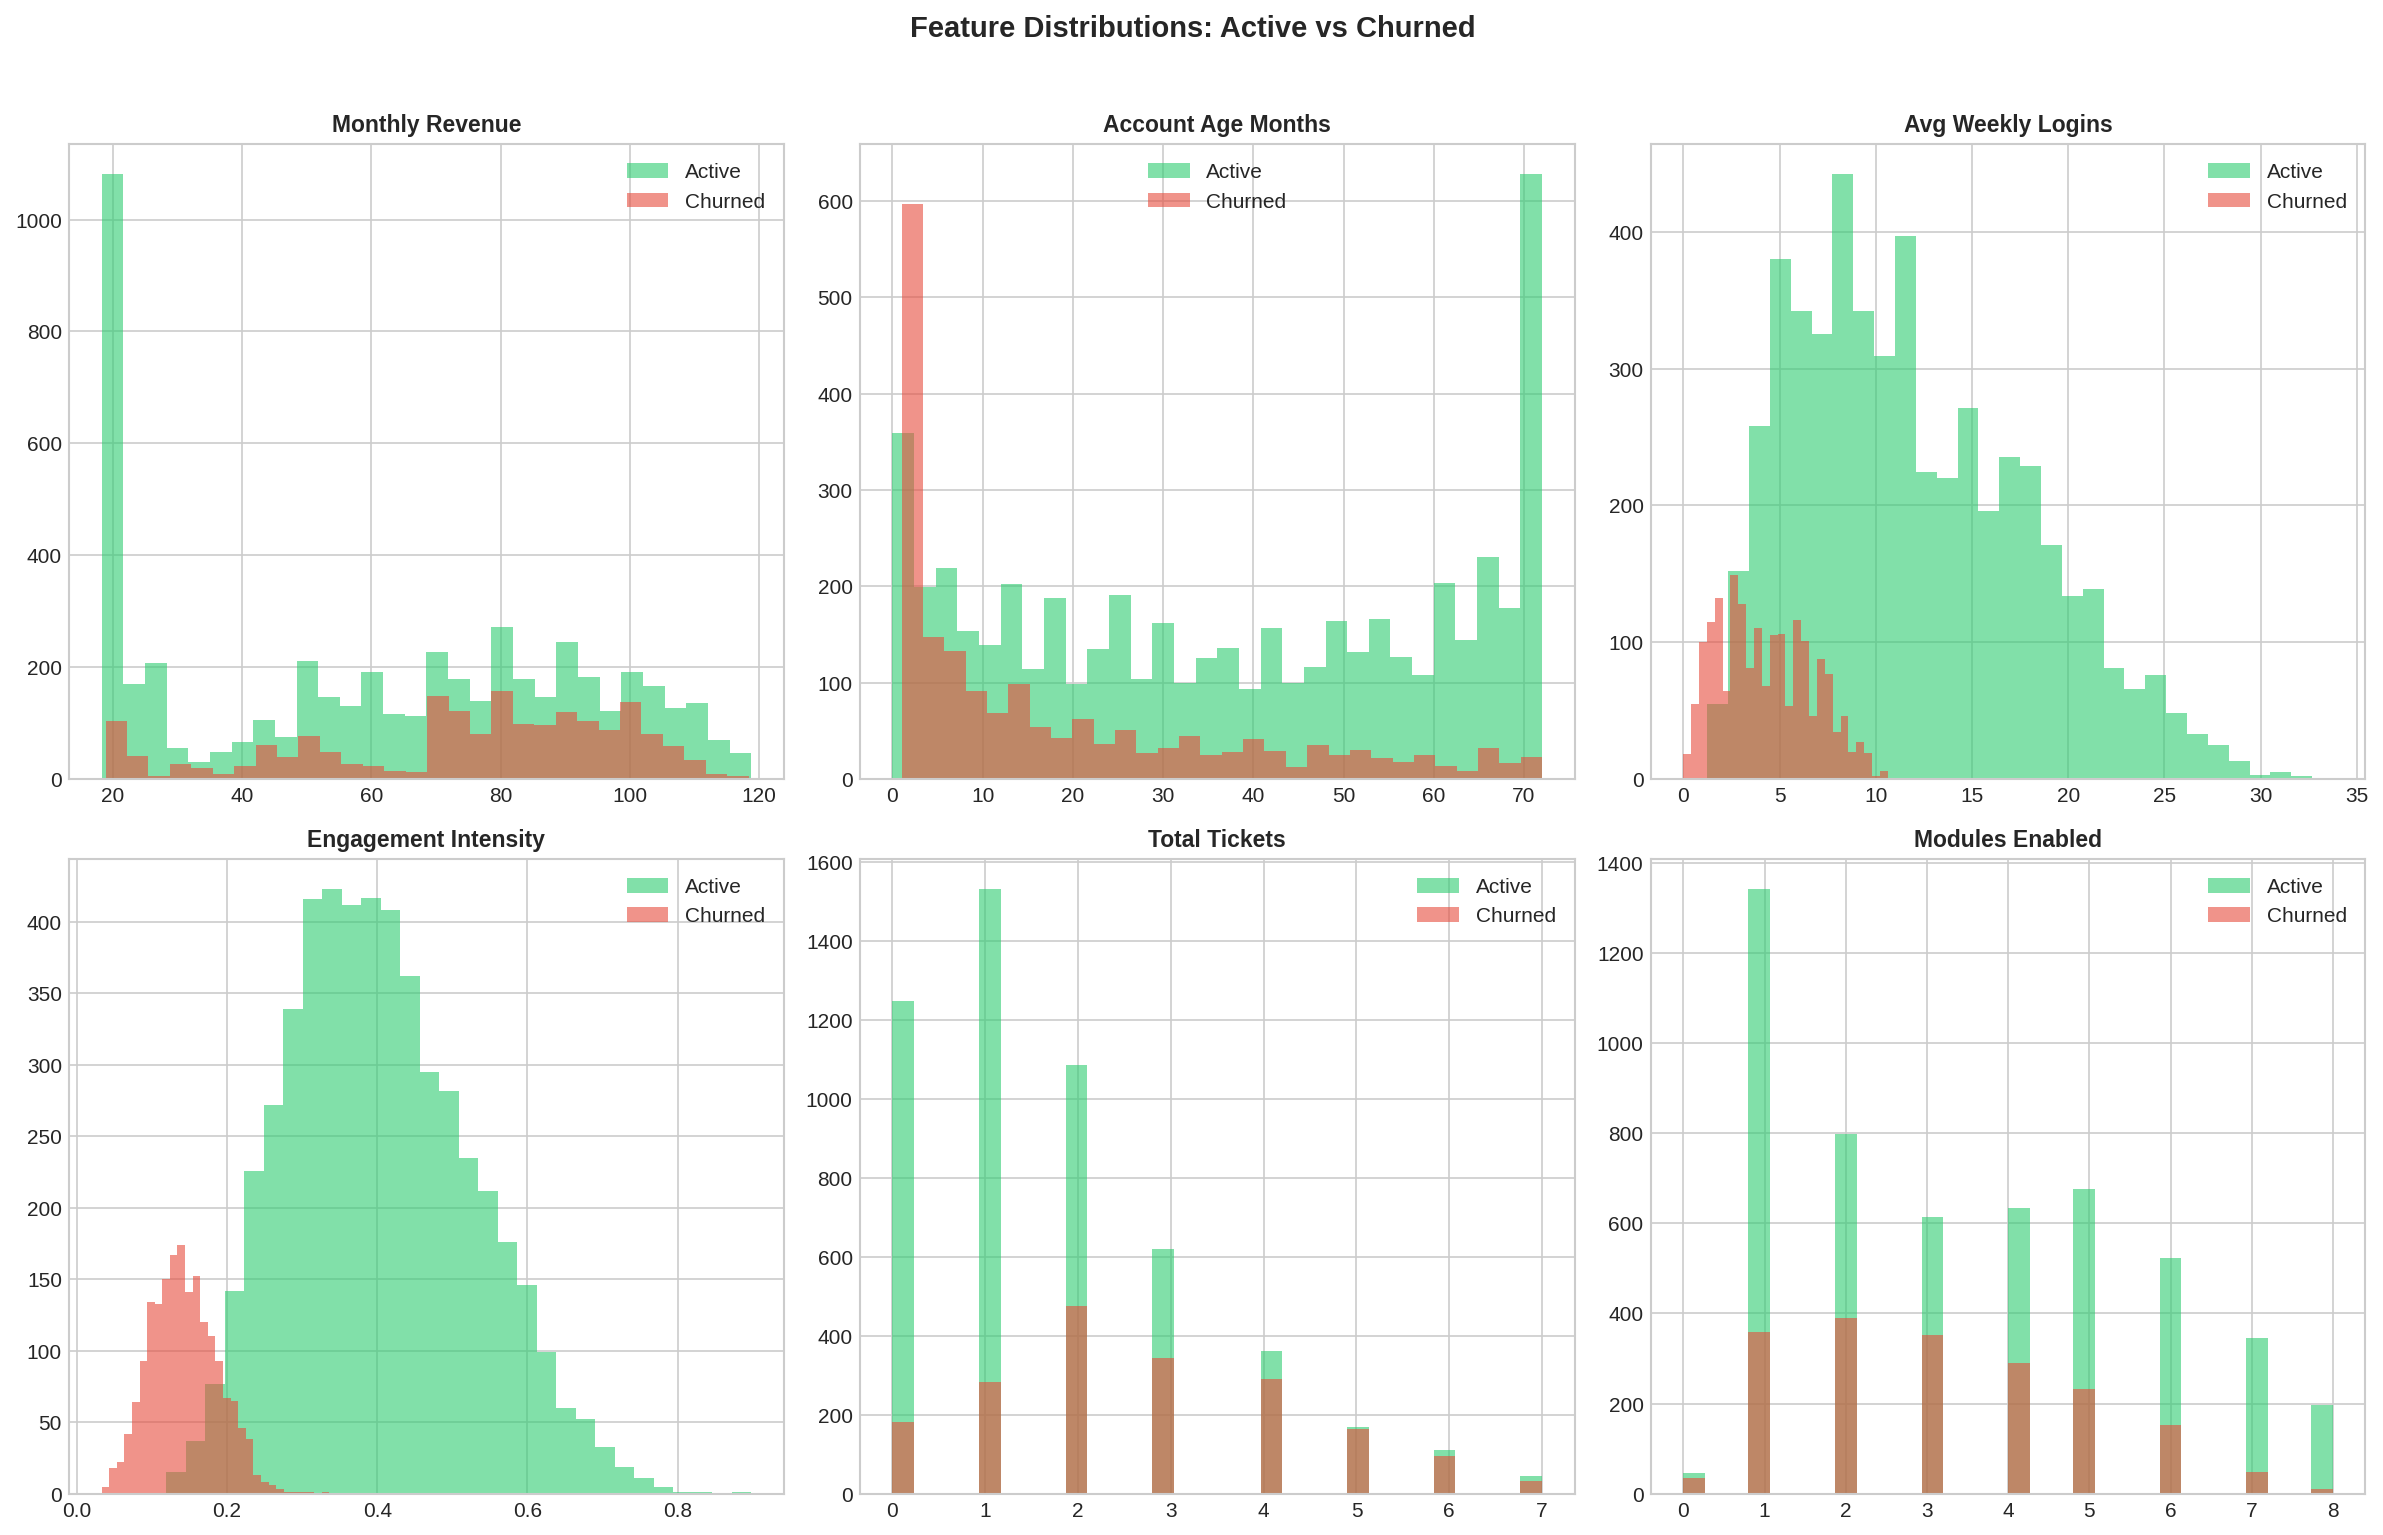


── feature_importance.png ──


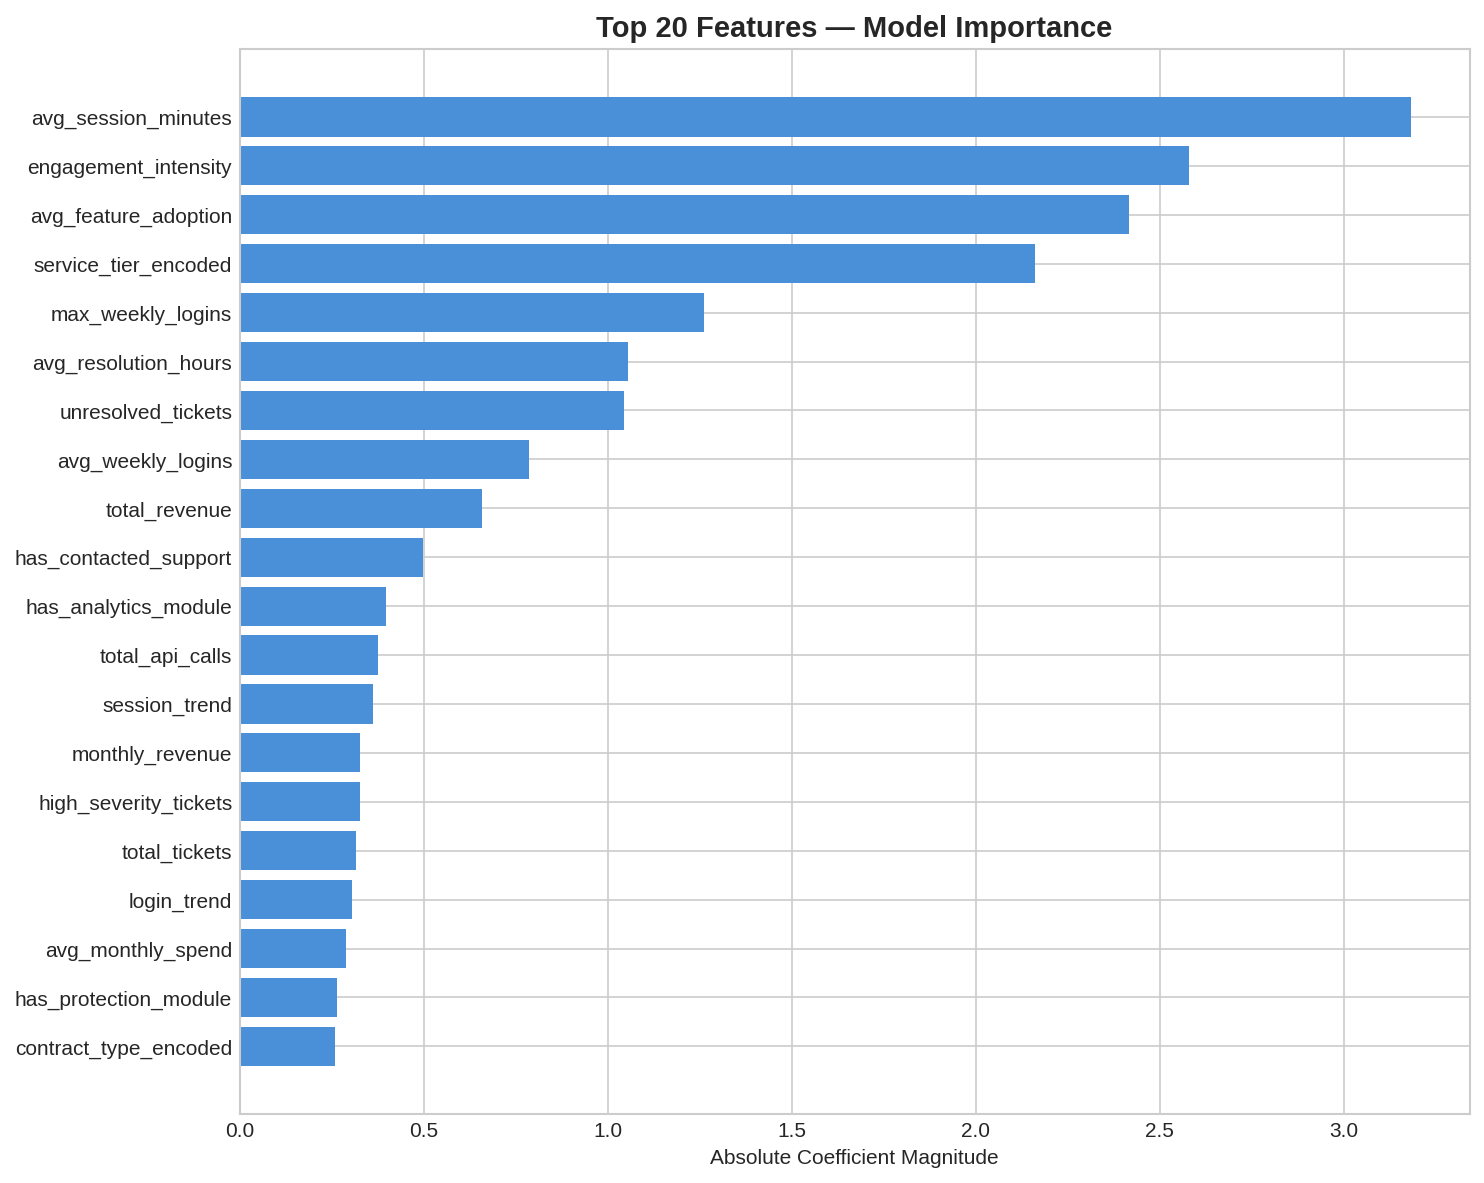


── model_comparison.png ──


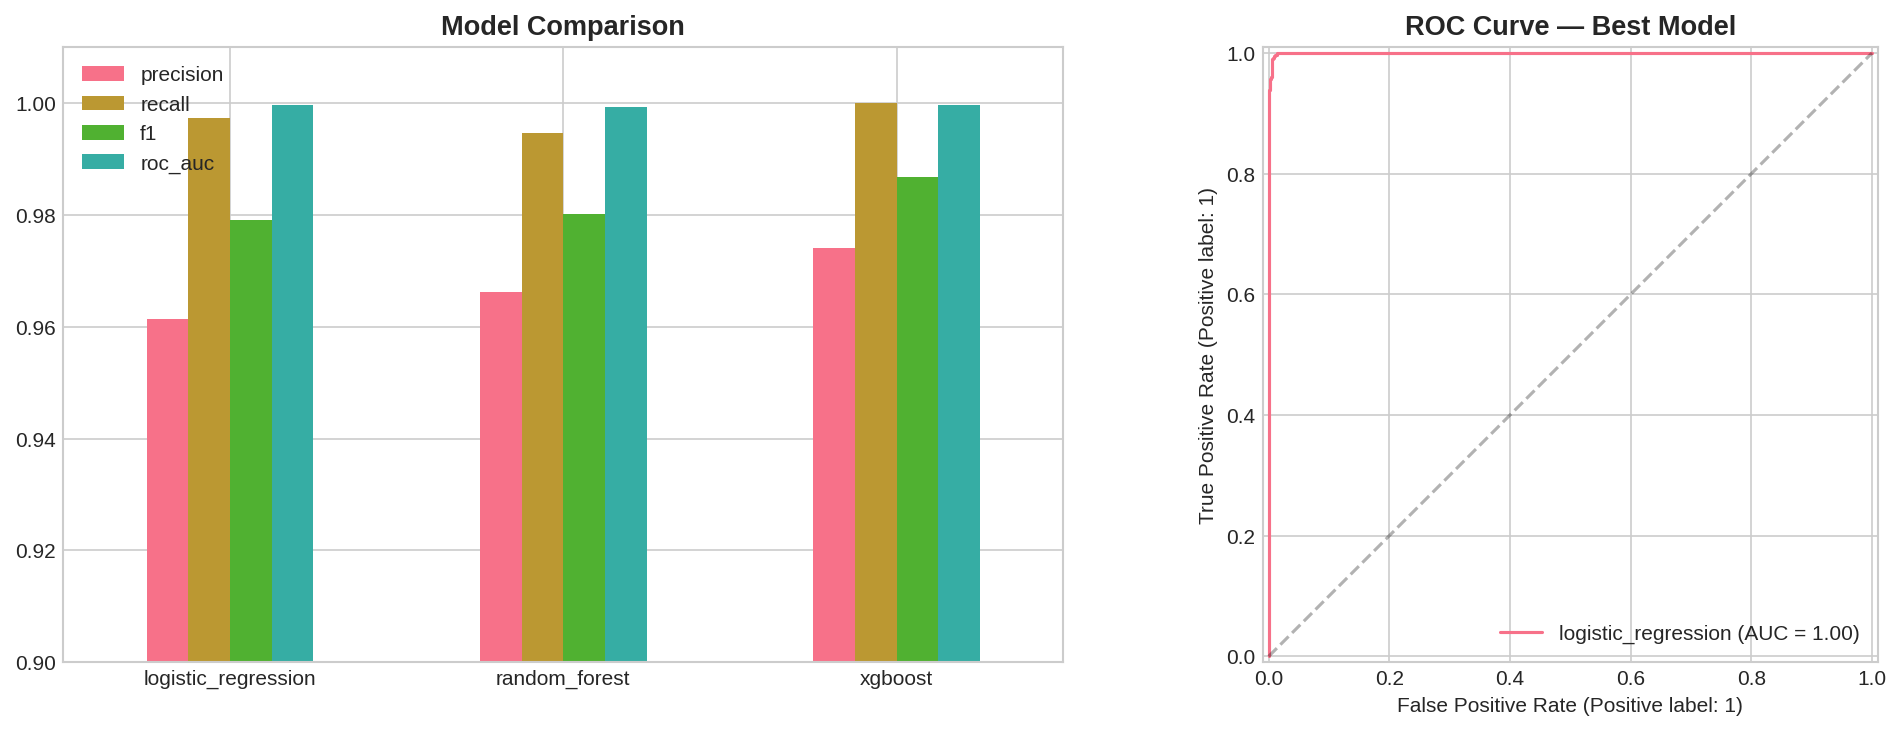


── precision_recall_curve.png ──


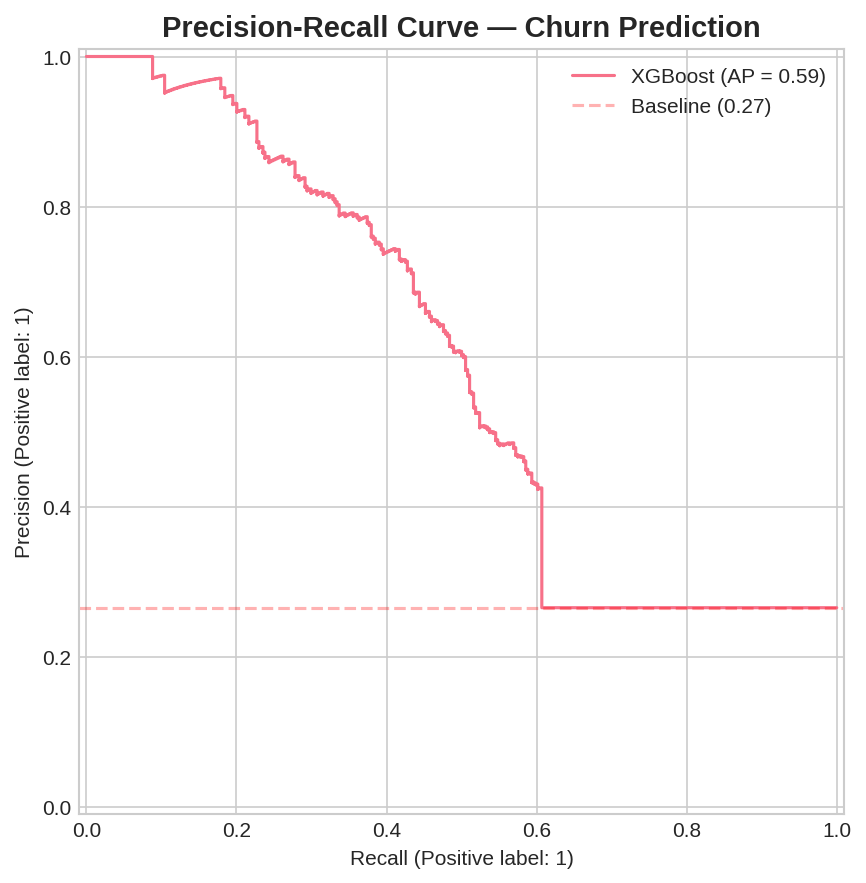


── roc_curve.png ──


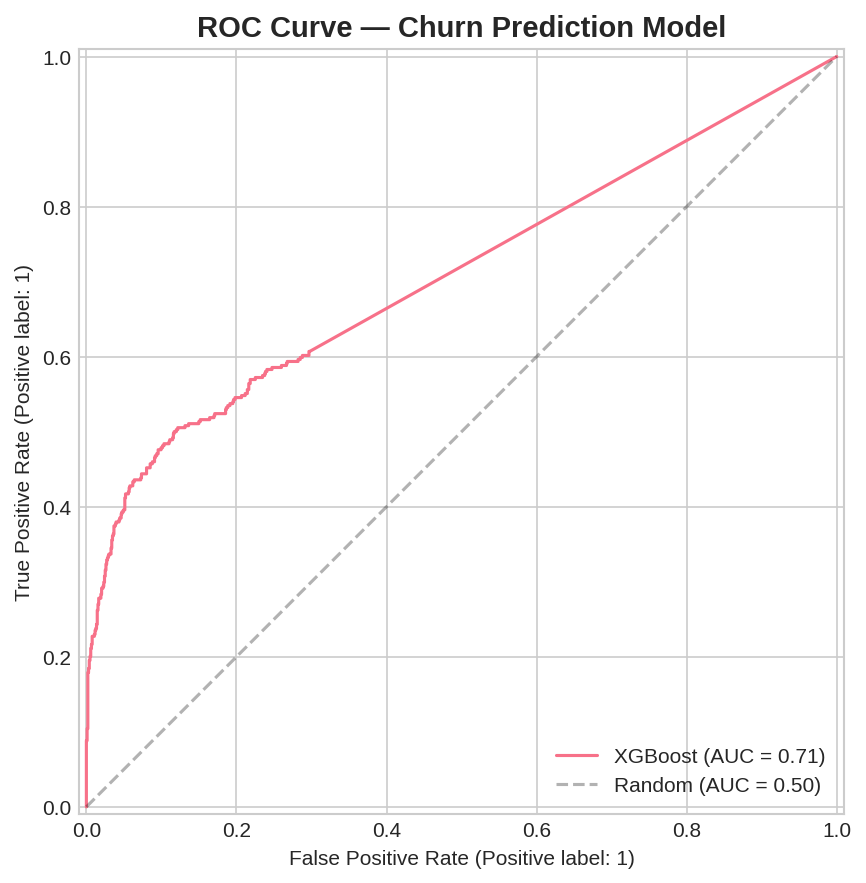


── shap_bar.png ──


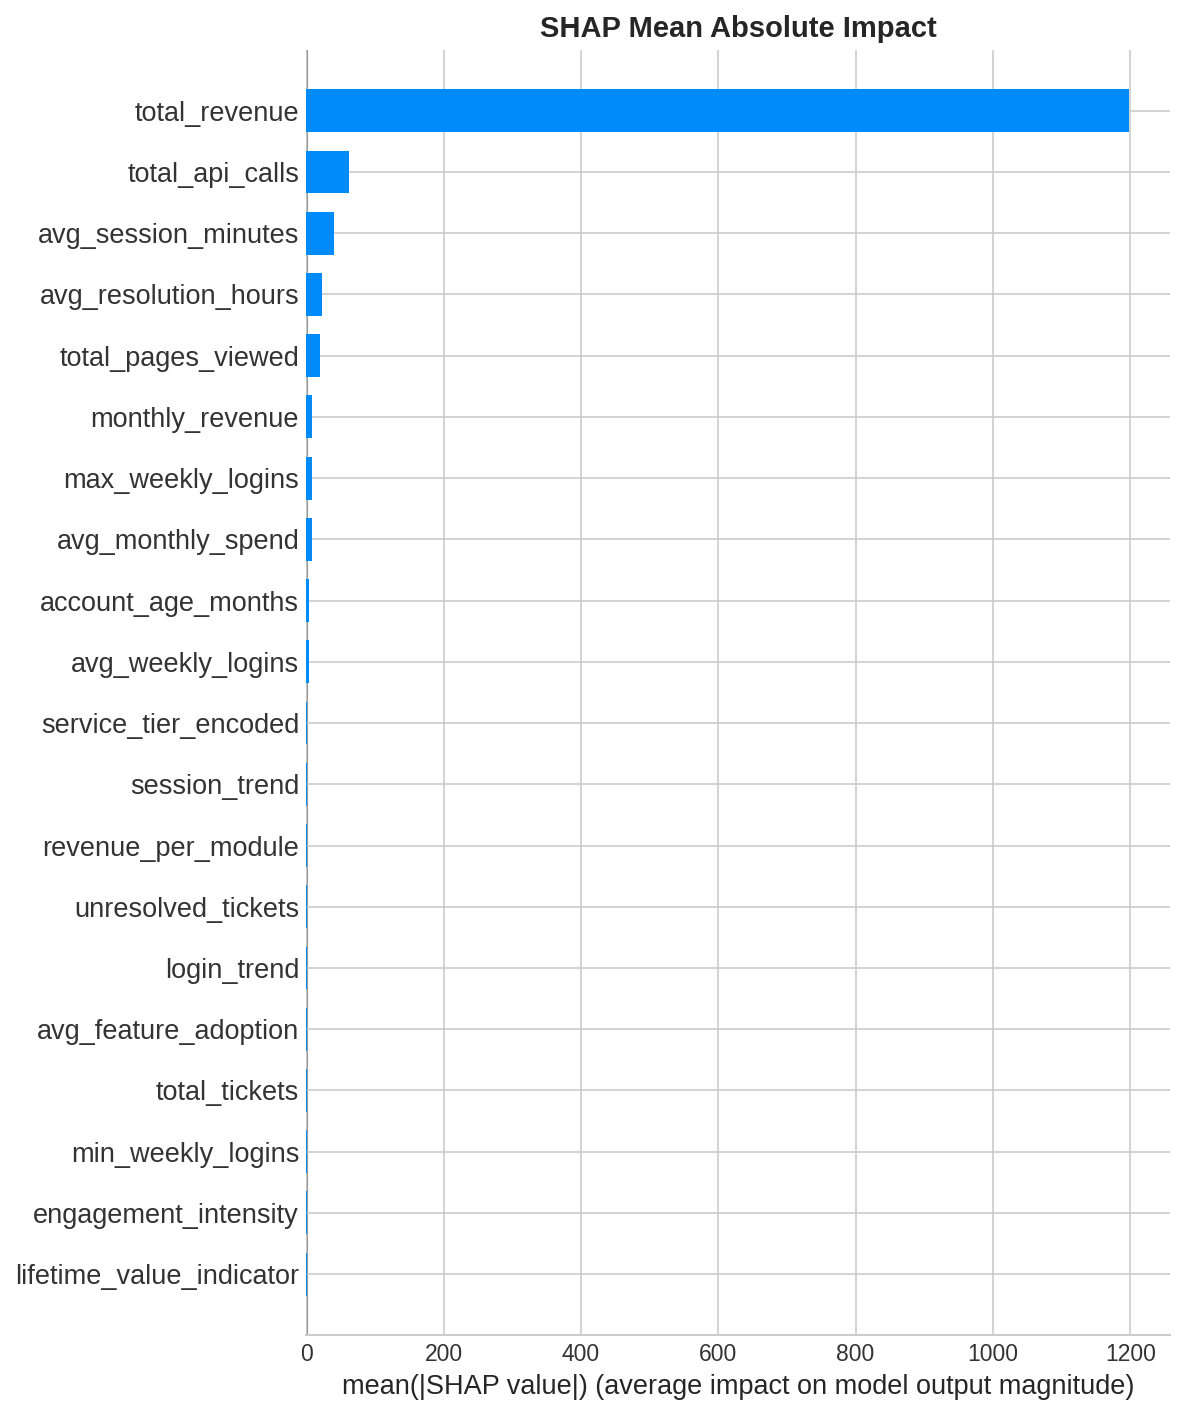


── shap_summary.png ──


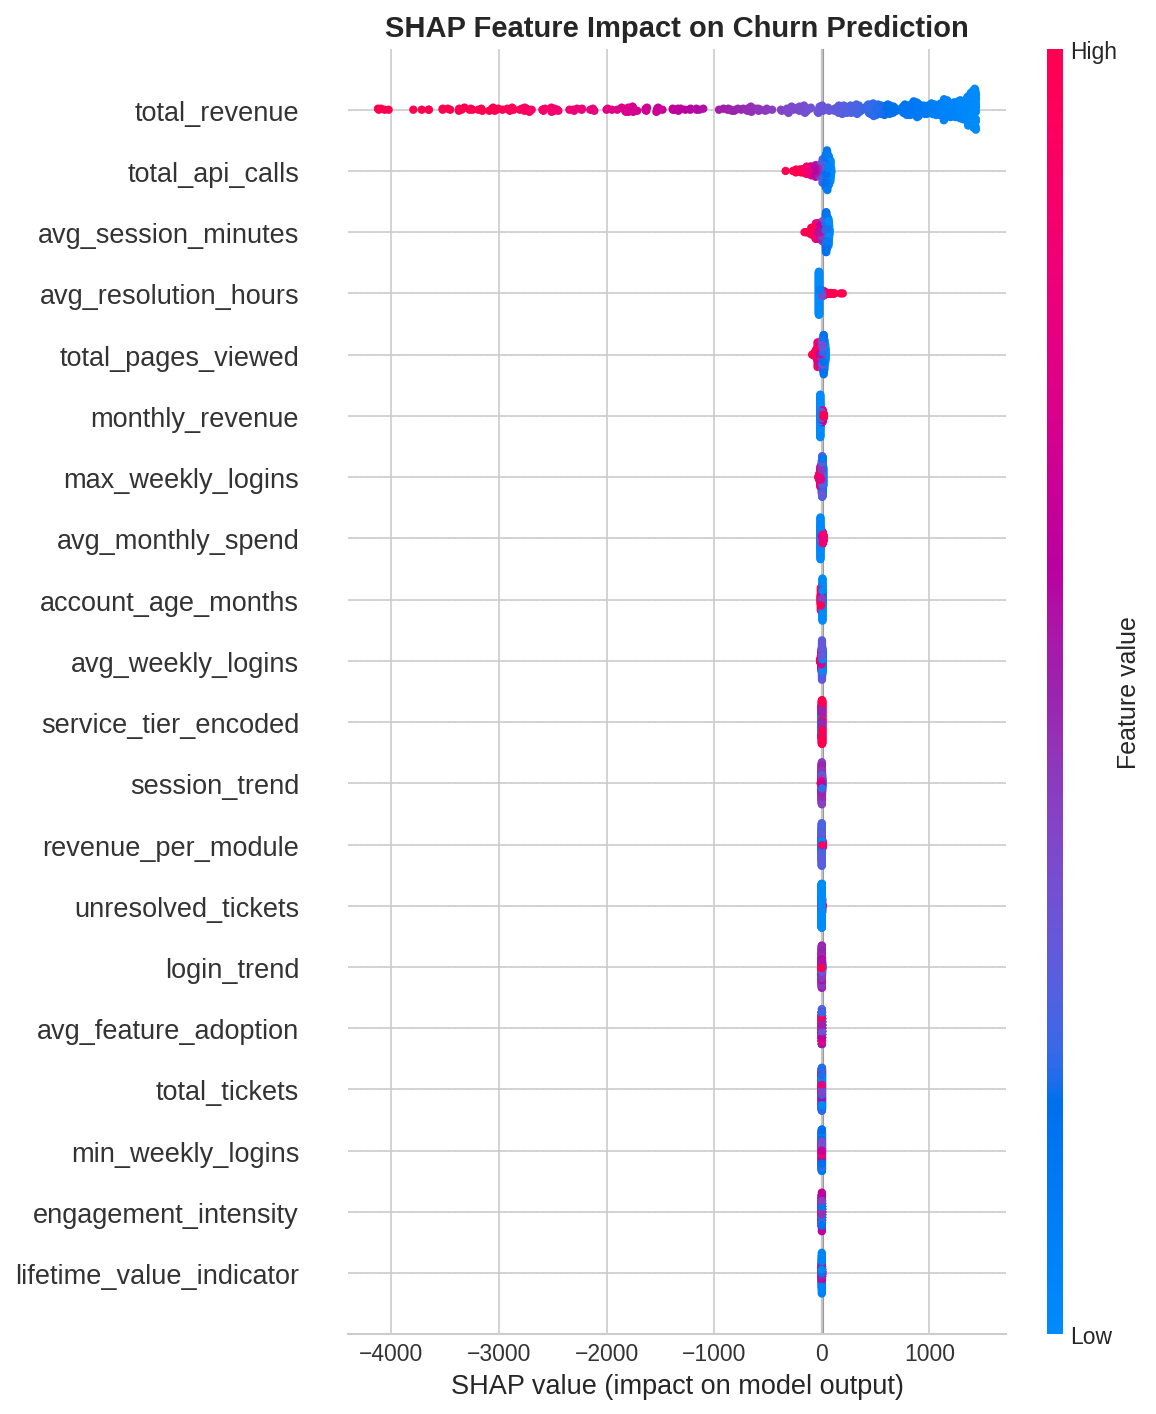


── shap_waterfall.png ──


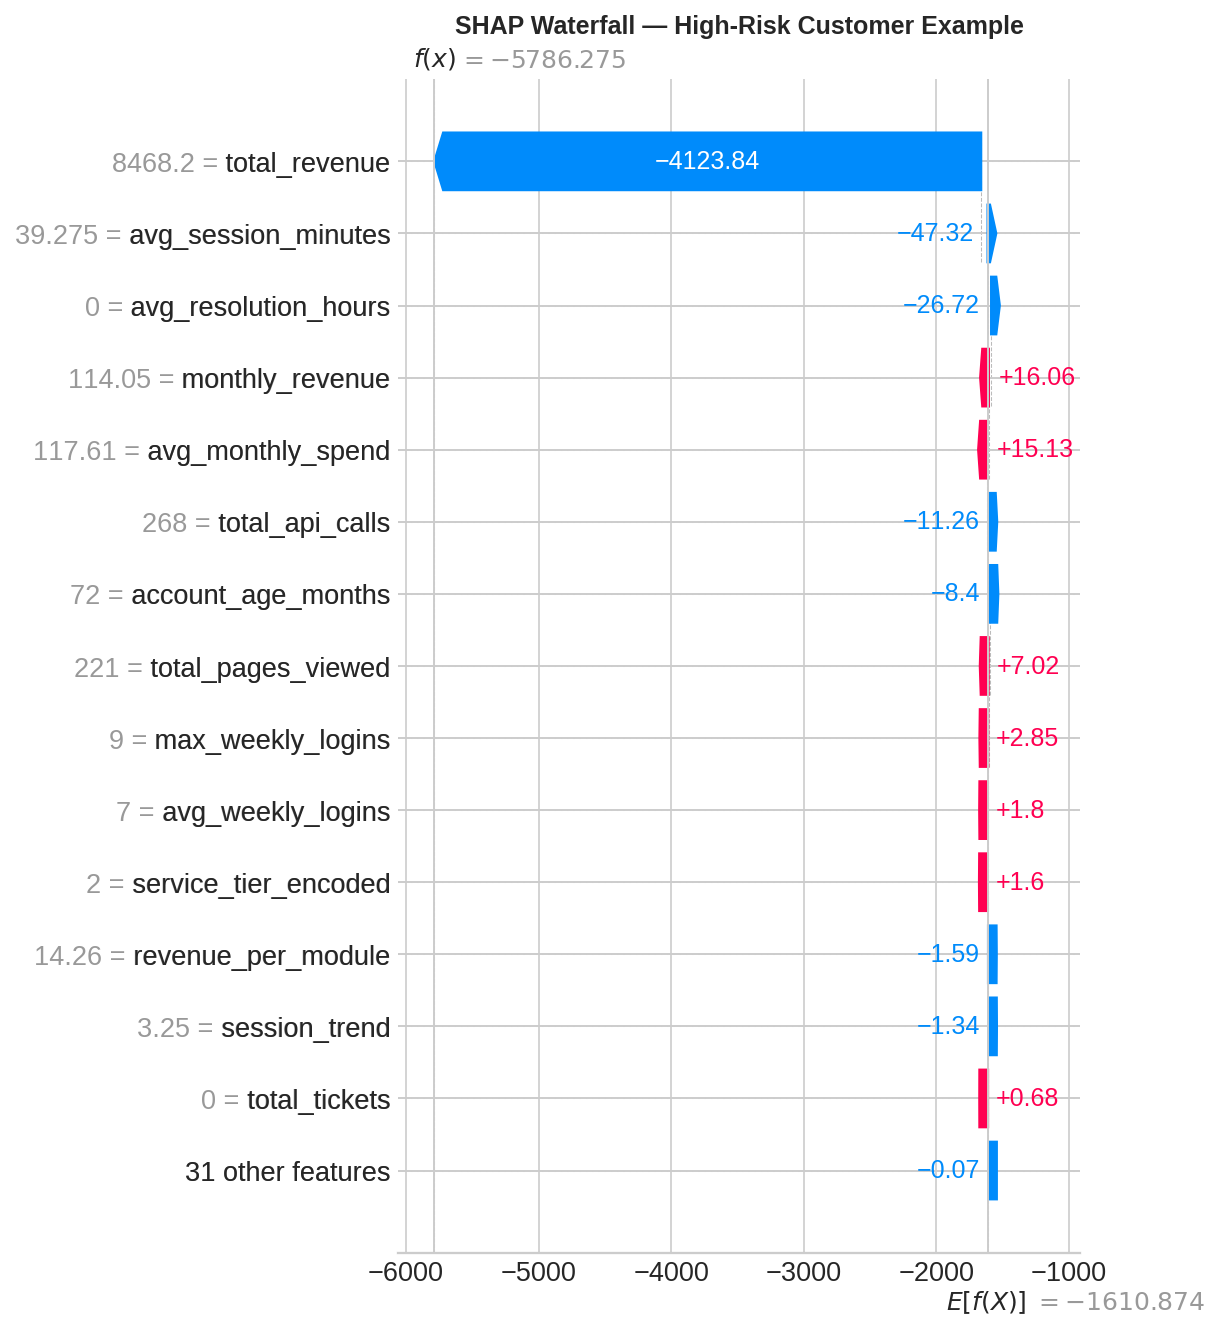

In [16]:
# Display ALL saved plots
from IPython.display import Image, display
import os

print(f"\n{'═' * 50}")
print(f"  All plots in models/plots/:")
print(f"{'═' * 50}")

plots_dir = "models/plots"
for plot_name in sorted(os.listdir(plots_dir)):
    if plot_name.endswith(".png"):
        print(f"\n── {plot_name} ──")
        display(Image(filename=os.path.join(plots_dir, plot_name), width=700))

## 2.4 Batch Scoring
Calls `src/models/predict.py` — scores all customers with risk levels.

In [17]:
from src.models.predict import predict_batch

scored = predict_batch()
scored.to_csv("data/processed/scored_customers.csv", index=False)

print("\nTop 10 highest-risk customers:")
scored.head(10)

  Scored 7,043 customers
  Risk distribution:
risk_level
low         2587
critical      89
medium         1
high           0

  Revenue at risk (predicted churners): £3,874.50/month

Top 10 highest-risk customers:


,customer_id,churn_probability,churn_prediction,monthly_revenue,risk_level,actual_churn
6969,4745-LSPLO,1.0,1,20.50,critical,1
3030,1761-AEZZR,1.0,1,79.55,critical,1
1494,2667-WYLWJ,1.0,1,19.75,critical,1
6796,8450-JOVAH,1.0,1,56.70,critical,1
660,5650-VDUDS,1.0,1,24.25,critical,1
3241,3148-BLQJT,1.0,1,20.10,critical,1
5498,1976-CFOCS,1.0,1,46.00,critical,1
2821,4102-OQUPX,1.0,1,74.40,critical,1
252,9514-JDSKI,1.0,1,40.20,critical,1
383,5167-ZFFMM,1.0,1,90.85,critical,1


## 2.5 Revenue Impact Summary

In [18]:
import joblib
meta = joblib.load("models/model_metadata.joblib")
rev = meta["revenue_impact"]

print("╔══════════════════════════════════════════════════╗")
print("║         REVENUE IMPACT ESTIMATION                ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  Total MRR at risk:          £{rev['total_mrr_at_risk']:>10,.2f}        ║")
print(f"║  MRR identified by model:    £{rev['mrr_identified']:>10,.2f}        ║")
print(f"║  Est. annual savings:        £{rev['estimated_annual_savings']:>10,.2f}        ║")
print("╚══════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════╗
║         REVENUE IMPACT ESTIMATION                ║
╠══════════════════════════════════════════════════╣
║  Total MRR at risk:          £ 27,214.90        ║
║  MRR identified by model:    £ 26,945.35        ║
║  Est. annual savings:        £ 64,668.84        ║
╚══════════════════════════════════════════════════╝


## 2.6 All Generated Plots

In [19]:
# Final inventory of all saved plots
import os
plots_dir = "models/plots"
print(f"Total plots saved to {plots_dir}/:")
print()
for f in sorted(os.listdir(plots_dir)):
    if f.endswith(".png"):
        size_kb = os.path.getsize(os.path.join(plots_dir, f)) / 1024
        print(f"  ✓ {f} ({size_kb:.0f} KB)")

Total plots saved to models/plots/:

  ✓ confusion_matrix.png (38 KB)
  ✓ eda_churn_by_segments.png (66 KB)
  ✓ eda_churn_distribution.png (44 KB)
  ✓ eda_correlation_heatmap.png (184 KB)
  ✓ eda_feature_distributions.png (123 KB)
  ✓ feature_importance.png (100 KB)
  ✓ model_comparison.png (75 KB)
  ✓ precision_recall_curve.png (51 KB)
  ✓ roc_curve.png (63 KB)
  ✓ shap_bar.png (133 KB)
  ✓ shap_summary.png (173 KB)
  ✓ shap_waterfall.png (160 KB)


---
## Summary — Technologies & Skills Demonstrated

| Skill | How It's Used | Files |
|---|---|---|
| **Python** | Core language for all pipelines | `src/data/*.py`, `src/models/*.py` |
| **SQL** | Feature engineering with CTEs, window functions, JOINs | `src/sql/features.sql`, `src/sql/init.sql` |
| **SQLite/PostgreSQL** | Relational database for structured data storage | `src/db.py`, `docker-compose.yml` |
| **scikit-learn** | Logistic Regression, Random Forest, preprocessing | `src/models/train.py` |
| **XGBoost** | Gradient boosted trees for tabular prediction | `src/models/train.py` |
| **MLflow** | Experiment tracking and model registry | `src/models/train.py` |
| **SHAP** | Model explainability (global + local) | `src/models/evaluate.py` |
| **Docker** | Containerised PostgreSQL database | `docker-compose.yml` |
| **Makefile** | Pipeline automation (Bash) | `Makefile` |
| **Modular Architecture** | Modular `src/` package structure | entire `src/` directory |

**Next:** Phase 3 (FastAPI endpoint) and Phase 4 (Streamlit dashboard)